# 02 障碍期权：为什么求导需要 fuzzy 平滑

如果用 `jnp.where` 做障碍判断，再直接套 `jax.grad`，会得到 `d_BARRIER = 0`，`d_vol` 和 `d_spot` 也和 DAL 对不上。
这个例子说明原因，并用移植自 DAL 的 CSpr 平滑核（`dal_jax.script.lower.cspr`）得到正确的 Greeks：

1. 硬判断的路径导数丢掉了"穿越障碍"那一项；
2. fuzzy 模式把 `IF spot() >= BARRIER` 换成 CSpr 混合，导数恢复；
3. 用有限差分验证，并和 DAL 的 AAD 结果逐位对照（含 Brownian bridge）。

In [1]:
import os

import dal_jax as dj

# Split the CPU into virtual devices so Monte Carlo blocks run in parallel.
# JAX only accepts this before its first operation, so keep it at the top.
dj.config.configure(num_cpu_devices=min(8, os.cpu_count() or 1))

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from nbtools import AQUA, BLUE, MUTED, ORANGE, apply_style, label_end, show_table

try:
    import dal  # dal-python, only used for side-by-side comparisons
except ImportError:
    dal = None

apply_style()
print(f"jax {jax.__version__}: {len(jax.devices())} x {jax.devices()[0].platform} device(s); dal-python: {dal is not None}")

starting DAL with: 32 threads.
use AAD framework: AADET
starting initialization global data ...
finished initialization all the global information.
jax 0.11.2: 8 x cpu device(s); dal-python: True


## 1. 产品：按月观察的向上敲出看涨期权

对应 DAL 的事件表：

| 日期 | 事件 |
|---|---|
| 今天 2022-09-15 | `alive = 1` |
| `START: 2022-09-15 END: 2025-09-14 FREQ: 1M` | `if spot() >= BARRIER:0.1 then alive = 0 end` |
| 2025-09-14 | `if spot() >= BARRIER:0.1 then alive = 0 end` <br> `call pays alive * MAX(spot() - STRIKE, 0.0)` |

月度日程的最后一天就是到期日，DAL 会把它和最后一行合并，所以**到期日的障碍判断执行两次**。
exact 模式下这没有影响，但 fuzzy 模式下生存因子会乘两次，手写 payoff 也照此处理才能和 DAL 一致。时间轴使用 ACT/365F。

In [2]:
import datetime as dt

TODAY = dt.date(2022, 9, 15)
MATURITY = TODAY + dt.timedelta(days=3 * 365)
dates = [TODAY]
for k in range(1, 36):
    month = TODAY.month - 1 + k
    dates.append(dt.date(TODAY.year + month // 12, month % 12 + 1, TODAY.day))
dates.append(MATURITY)
timeline = tuple((d - TODAY).days / 365.0 for d in dates)
print(f"{len(timeline)} dates: {dates[0]} ... {dates[-1]}, last time = {timeline[-1]:.6f}")

37 dates: 2022-09-15 ... 2025-09-14, last time = 3.000000


payoff 用 `ctx.fuzzy` 切换两种求值方式：

- exact：`hit = (spot >= BARRIER)`，与 DAL 的 `Evaluator_` 相同；
- fuzzy：`hit = CSpr(spot - BARRIER, 0.1)`，`IF hit THEN alive = 0` 变成混合 `alive = hit * 0 + (1 - hit) * alive`，与 DAL 的 `FuzzyEvaluator_` 相同。

`scenario.samples()` 一次性把路径拆成逐日期的视图。逐个写 `scenario.spot[i]` 也能算出同样的结果，但每个静态切片在反向传播里都会变成一次整块的 `pad`，在 CPU 上慢一个数量级。

In [3]:
from dal_jax.script.lower import cspr

SPOT, VOL, RATE, DIV = 100.0, 0.15, 0.05, 0.03
STRIKE, BARRIER, EPS = 120.0, 150.0, 0.1
BARRIER_DATES = list(range(1, len(timeline))) + [len(timeline) - 1]  # maturity is tested twice, as in DAL


def up_and_out(params, scenario, ctx):
    barrier, strike = params["script"]["BARRIER"], params["script"]["STRIKE"]
    samples = scenario.samples()
    alive = 1.0
    for i in BARRIER_DATES:
        x = samples[i].spot - barrier
        hit = cspr(x, EPS) if ctx.fuzzy else (x >= 0.0).astype(x.dtype)
        alive = alive * (1.0 - hit)
    last = samples[-1]
    return alive * jnp.maximum(last.spot - strike, 0.0) / last.numeraire


product = dj.PathProduct(
    timeline=timeline, payoff=up_and_out, payoff_names=("call",), script_params={"STRIKE": STRIKE, "BARRIER": BARRIER}
)
model = dj.BlackScholes(spot=SPOT, vol=VOL, rate=RATE, div=DIV)
engine = dj.MonteCarloEngine(product, model)
params = engine.default_params()
N_PATHS = 2**20

## 2. 硬判断下的梯度：`d_BARRIER` 恒为 0

`engine.pricer(n, fuzzy=False)` 返回 exact 模式下的纯函数，直接套 `jax.value_and_grad`。
指示函数对障碍位置的导数几乎处处为 0，所以 `d_BARRIER` 精确等于 0；`d_spot`、`d_vol` 也只剩下"没有穿越障碍"的那部分贡献。

In [4]:
def risks(grads):
    names = [("model", label) for label in model.param_labels] + [("script", name) for name in ("STRIKE", "BARRIER")]
    return {f"d_{name}": float(grads[group][name]) for group, name in names}


hard_pv, hard_grads = jax.jit(jax.value_and_grad(lambda p: engine.pricer(N_PATHS, fuzzy=False)(p)[0]))(params)
hard = {"PV": float(hard_pv)} | risks(hard_grads)
show_table(["结果", "硬判断 + jax.grad"], [[k, v] for k, v in hard.items()], fmt="{:.8f}")

| 结果 | 硬判断 + jax.grad |
|:---|---:|
| PV | 1.50576282 |
| d_spot | 0.18364763 |
| d_vol | 21.52395954 |
| d_rate | 50.57700180 |
| d_div | -55.09429027 |
| d_STRIKE | -0.14049167 |
| d_BARRIER | 0.00000000 |

## 3. CSpr：把障碍判断平滑成一个窄斜坡

CSpr 在 `[-ε/2, ε/2]` 内从 0 线性升到 1，区间外和硬判断完全相同。它对障碍位置有非零导数，于是"穿越障碍"的贡献回到了路径导数里。
ε 取节点自带的 `:0.1`（没有时用 `MonteCarloSettings.smooth`，默认 0.01，与 DAL 一致）。

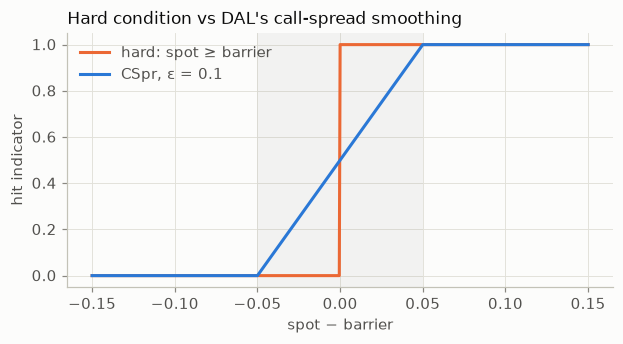

In [5]:
x = np.linspace(-0.15, 0.15, 601)
fig, ax = plt.subplots(figsize=(6.4, 3.0))
ax.plot(x, (x >= 0).astype(float), color=ORANGE, label="hard: spot ≥ barrier")
ax.plot(x, np.asarray(cspr(x, EPS)), color=BLUE, label=f"CSpr, ε = {EPS}")
ax.axvspan(-EPS / 2, EPS / 2, color=MUTED, alpha=0.08, linewidth=0)
ax.set_xlabel("spot − barrier")
ax.set_ylabel("hit indicator")
ax.set_title("Hard condition vs DAL's call-spread smoothing")
ax.legend(loc="upper left")
plt.show()

`enable_aad=True` 时，引擎用 fuzzy 模式同时得到价格和全部 Greeks，与 DAL 的 `MonteCarlo_Value(..., enable_aad=True)` 相同。
fuzzy 价格比 exact 价格略低一点，这是平滑带来的偏差，DAL 也一样。

In [6]:
fuzzy_engine = dj.MonteCarloEngine(product, model, dj.MonteCarloSettings(enable_aad=True))
fuzzy = fuzzy_engine.value(N_PATHS)
exact_pv = engine.value(N_PATHS)["PV"]
rows = [["PV", exact_pv, hard["PV"], fuzzy["PV"]]] + [[k, "", hard[k], fuzzy[k]] for k in fuzzy if k != "PV"]
show_table(["结果", "exact 价格", "硬判断 + jax.grad", "fuzzy + jax.grad"], rows, fmt="{:.8f}")

| 结果 | exact 价格 | 硬判断 + jax.grad | fuzzy + jax.grad |
|:---|---:|---:|---:|
| PV | 1.50576282 | 1.50576282 | 1.50524290 |
| d_spot |  | 0.18364763 | 0.04974902 |
| d_vol |  | 21.52395954 | -7.22701532 |
| d_rate |  | 50.57700180 | 14.86550100 |
| d_div |  | -55.09429027 | -19.38122970 |
| d_STRIKE |  | -0.14049167 | -0.14047464 |
| d_BARRIER |  | 0.00000000 | 0.08925165 |

## 4. 用有限差分验证 `d_BARRIER`

先在 BARRIER = 150 处做两种检查（都用共同随机数，即同一批 Sobol 路径）：

- **fuzzy 价格**的中心差分（步长 1e-6）：检验 `jax.grad` 对 fuzzy 价格求导本身是否正确，两者应当几乎逐位相同；
- **exact 价格**的中心差分（步长 1）：检验 fuzzy 导数是否抓住了真实的障碍敏感度。

In [7]:
exact_f = jax.jit(engine.pricer(N_PATHS, fuzzy=False))
fuzzy_f = jax.jit(engine.pricer(N_PATHS, fuzzy=True))


def with_barrier(b):
    return {"model": params["model"], "script": params["script"] | {"BARRIER": b}}


def central_difference(f, b, h):
    return (float(f(with_barrier(b + h))[0]) - float(f(with_barrier(b - h))[0])) / (2.0 * h)


fuzzy_grad = float(jax.grad(lambda b: fuzzy_f(with_barrier(b))[0])(BARRIER))
show_table(["BARRIER = 150 处的斜率", "值", "与 fuzzy jax.grad 的相对差异"], [
    ["fuzzy 价格 + jax.grad", f"{fuzzy_grad:.10f}", ""],
    ["fuzzy 价格的中心差分，h = 1e-6", f"{central_difference(fuzzy_f, BARRIER, 1e-6):.10f}",
     f"{abs(central_difference(fuzzy_f, BARRIER, 1e-6) / fuzzy_grad - 1):.1e}"],
    ["exact 价格的中心差分，h = 1", f"{central_difference(exact_f, BARRIER, 1.0):.10f}",
     f"{abs(central_difference(exact_f, BARRIER, 1.0) / fuzzy_grad - 1):.1e}"],
    ["硬判断 + jax.grad", f"{hard['d_BARRIER']:.10f}", ""],
])

| BARRIER = 150 处的斜率 | 值 | 与 fuzzy jax.grad 的相对差异 |
|:---|---:|---:|
| fuzzy 价格 + jax.grad | 0.0892516541 |  |
| fuzzy 价格的中心差分，h = 1e-6 | 0.0892516538 | 3.2e-09 |
| exact 价格的中心差分，h = 1 | 0.0892751765 | 2.6e-04 |
| 硬判断 + jax.grad | 0.0000000000 |  |

再在一串障碍水平上比较三种斜率。`jax.lax.map(..., batch_size=7)` 把多次定价按 7 个一批 `vmap` 起来，这是 issue #1 里"业务维度上的额外 vmap 轴"的一个例子。

fuzzy 导数沿障碍水平有些起伏：ε = 0.1 的平滑带很窄，只有恰好贴近障碍的路径对导数有贡献，所以估计量的方差比价格本身大。增大平滑宽度可以降低方差，但会带来更大的偏差，这是 DAL 也同样面对的取舍。

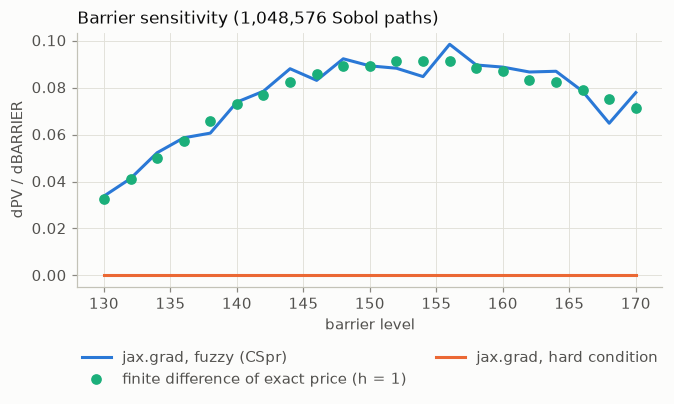

| BARRIER | fuzzy jax.grad | exact 价格的有限差分 | 硬判断 jax.grad |
|:---|---:|---:|---:|
| 130 | 0.03377 | 0.03254 | 0.00000 |
| 138 | 0.06060 | 0.06559 | 0.00000 |
| 146 | 0.08307 | 0.08579 | 0.00000 |
| 154 | 0.08468 | 0.09137 | 0.00000 |
| 162 | 0.08664 | 0.08318 | 0.00000 |
| 170 | 0.07786 | 0.07144 | 0.00000 |

In [8]:
levels = jnp.arange(130.0, 171.0, 2.0)
exact_ladder = engine.pricer(N_PATHS, fuzzy=False)
fuzzy_ladder = engine.pricer(N_PATHS, fuzzy=True)


def slope(f):
    return jax.jit(lambda bs: jax.lax.map(jax.grad(lambda b: f(with_barrier(b))[0]), bs, batch_size=7))(levels)


def prices(f, bs):
    return jax.jit(lambda bs: jax.lax.map(lambda b: f(with_barrier(b))[0], bs, batch_size=7))(bs)


hard_slope, fuzzy_slope = slope(exact_ladder), slope(fuzzy_ladder)
fd_slope = (prices(exact_ladder, levels + 1.0) - prices(exact_ladder, levels - 1.0)) / 2.0

fig, ax = plt.subplots(figsize=(6.4, 3.9))
ax.plot(levels, fuzzy_slope, color=BLUE, label="jax.grad, fuzzy (CSpr)")
ax.plot(levels, fd_slope, linestyle="none", marker="o", color=AQUA, label="finite difference of exact price (h = 1)")
ax.plot(levels, hard_slope, color=ORANGE, label="jax.grad, hard condition")
ax.set_xlabel("barrier level")
ax.set_ylabel("dPV / dBARRIER")
ax.set_title(f"Barrier sensitivity ({N_PATHS:,} Sobol paths)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
fig.tight_layout()
plt.show()

show_table(
    ["BARRIER", "fuzzy jax.grad", "exact 价格的有限差分", "硬判断 jax.grad"],
    [[f"{b:.0f}", float(f), float(d), float(h)] for b, f, d, h in zip(levels[::4], fuzzy_slope[::4], fd_slope[::4], hard_slope[::4])],
    fmt="{:.5f}",
)

## 5. 与 DAL 对照：exact / fuzzy × 是否使用 Brownian bridge（需要 dal-python）

DAL 的 Brownian bridge 用单位步长构造（不是真实事件时间），`dal_jax` 照此移植，所以开关 `use_bb` 时两边仍然处理同一批路径。

In [9]:
if dal is None:
    print("dal-python 未安装，跳过对照。")
else:
    today = dal.Date_(2022, 9, 15)
    dal.EvaluationDate_Set(today)
    maturity = today.AddDays(3 * 365)
    dal_product = dal.Product_New(
        ["STRIKE", "BARRIER", today, f"START: {today} END: {maturity} FREQ: 1M", maturity],
        [f"{STRIKE:.2f}", f"{BARRIER:.2f}", "alive = 1", "if spot() >= BARRIER:0.1 then alive = 0 end",
         "if spot() >= BARRIER:0.1 then alive = 0 end\ncall pays alive * MAX(spot() - STRIKE, 0.0)"],
    )
    dal_model = dal.BSModelData_New(SPOT, VOL, RATE, DIV)
    rows = []
    for use_bb in (False, True):
        for aad in (False, True):
            ours = dj.MonteCarloEngine(product, model, dj.MonteCarloSettings(use_bb=use_bb, enable_aad=aad)).value(N_PATHS)
            theirs = dict(dal.MonteCarlo_Value(dal_product, dal_model, N_PATHS, "sobol", use_bb, aad))
            worst = max(abs(ours[k] / theirs[k] - 1) for k in ours)
            rows.append([f"use_bb={use_bb}, aad={aad}", f"{ours['PV']:.12f}", f"{theirs['PV']:.12f}",
                         f"{ours['d_BARRIER']:.10f}" if aad else "—", f"{theirs['d_BARRIER']:.10f}" if aad else "—", f"{worst:.1e}"])
    show_table(["设置", "PV (dal_jax)", "PV (DAL)", "d_BARRIER (dal_jax)", "d_BARRIER (DAL)", "最大相对差异"], rows)

| 设置 | PV (dal_jax) | PV (DAL) | d_BARRIER (dal_jax) | d_BARRIER (DAL) | 最大相对差异 |
|:---|---:|---:|---:|---:|---:|
| use_bb=False, aad=False | 1.505762822902 | 1.505762822902 | — | — | 3.3e-16 |
| use_bb=False, aad=True | 1.505242897852 | 1.505242897852 | 0.0892516541 | 0.0892516541 | 6.1e-12 |
| use_bb=True, aad=False | 1.501191459462 | 1.501191459462 | — | — | 4.4e-16 |
| use_bb=True, aad=True | 1.500588469045 | 1.500588469045 | 0.0969813452 | 0.0969813452 | 3.2e-13 |

## 小结

- 硬判断的 `jax.grad` 不是"不准"，而是在数学上就缺少边界项：对障碍位置的导数恒为 0；
- payoff 在 fuzzy 模式下用 `cspr`（相等判断用 `bfly`）平滑后，`jax.grad` 与有限差分、与 DAL 的 AAD 都一致；
- 后续的脚本引擎（P3）会自动完成这种 exact / fuzzy 两套降级，手写 payoff 只是在那之前的用法。